# 📊 Notebook 01 — Visão Geral e Qualidade dos Dados (Olist)

**Objetivo:** Carregar as 9 tabelas do dataset da Olist, realizar inspeção de qualidade (nulos, tipos, duplicatas), estatísticas descritivas básicas e gráficos de distribuição iniciais.

## 1. Importações e Configuração de Ambiente

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Detecção dinâmica de caminhos para dados e outputs
DATA_DIR = '../data/olist' if os.path.exists('../data/olist') else 'data/olist'
if not os.path.exists(DATA_DIR):
    DATA_DIR = '/home/jorge/Documents/tech-challenge-agentes-ia/data/olist'

OUTPUT_DIR = './outputs' if os.path.exists('./outputs') or os.path.basename(os.getcwd()) == 'notebooks' else 'notebooks/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"📁 Diretório de Dados: {os.path.abspath(DATA_DIR)}")
print(f"📁 Diretório de Outputs: {os.path.abspath(OUTPUT_DIR)}")


📁 Diretório de Dados: /home/jorge/Documents/tech-challenge-agentes-ia/data/olist
📁 Diretório de Outputs: /home/jorge/Documents/tech-challenge-agentes-ia/notebooks/outputs


## 2. Carregamento dos Datasets

In [2]:
files = {
    'customers': 'olist_customers_dataset.csv',
    'orders': 'olist_orders_dataset.csv',
    'order_items': 'olist_order_items_dataset.csv',
    'order_payments': 'olist_order_payments_dataset.csv',
    'order_reviews': 'olist_order_reviews_dataset.csv',
    'products': 'olist_products_dataset.csv',
    'sellers': 'olist_sellers_dataset.csv',
    'geolocation': 'olist_geolocation_dataset.csv',
    'category_translation': 'product_category_name_translation.csv'
}

data = {}
for name, file in files.items():
    filepath = os.path.join(DATA_DIR, file)
    try:
        data[name] = pd.read_csv(filepath)
        print(f"✓ Sucesso ao carregar {name}: {data[name].shape[0]} linhas, {data[name].shape[1]} colunas")
    except Exception as e:
        print(f"✗ Erro ao carregar {name}: {e}")


✓ Sucesso ao carregar customers: 99441 linhas, 5 colunas


✓ Sucesso ao carregar orders: 99441 linhas, 8 colunas


✓ Sucesso ao carregar order_items: 112650 linhas, 7 colunas
✓ Sucesso ao carregar order_payments: 103886 linhas, 5 colunas


✓ Sucesso ao carregar order_reviews: 99224 linhas, 7 colunas
✓ Sucesso ao carregar products: 32951 linhas, 9 colunas
✓ Sucesso ao carregar sellers: 3095 linhas, 4 colunas


✓ Sucesso ao carregar geolocation: 1000163 linhas, 5 colunas
✓ Sucesso ao carregar category_translation: 71 linhas, 2 colunas


## 3. Relatório de Qualidade e Estrutura dos Dados

In [3]:
for name, df in data.items():
    print(f"==================== TABELA: {name.upper()} ====================")
    print(f"Formato: {df.shape[0]} linhas × {df.shape[1]} colunas")
    print(f"Linhas duplicadas: {df.duplicated().sum()}")
    
    null_counts = df.isnull().sum()
    null_cols = null_counts[null_counts > 0]
    if len(null_cols) > 0:
        print("Valores Nulos:")
        for col, count in null_cols.items():
            pct = (count / len(df)) * 100
            print(f"  - {col}: {count} nulos ({pct:.2f}%)")
    else:
        print("Valores Nulos: Nenhum")
    print("-" * 60)


==================== TABELA: CUSTOMERS ====================
Formato: 99441 linhas × 5 colunas
Linhas duplicadas: 0
Valores Nulos: Nenhum
------------------------------------------------------------
==================== TABELA: ORDERS ====================
Formato: 99441 linhas × 8 colunas
Linhas duplicadas: 0
Valores Nulos:
  - order_approved_at: 160 nulos (0.16%)
  - order_delivered_carrier_date: 1783 nulos (1.79%)
  - order_delivered_customer_date: 2965 nulos (2.98%)
------------------------------------------------------------
==================== TABELA: ORDER_ITEMS ====================
Formato: 112650 linhas × 7 colunas
Linhas duplicadas: 0
Valores Nulos: Nenhum
------------------------------------------------------------
==================== TABELA: ORDER_PAYMENTS ====================
Formato: 103886 linhas × 5 colunas


Linhas duplicadas: 0


Valores Nulos: Nenhum
------------------------------------------------------------
==================== TABELA: ORDER_REVIEWS ====================
Formato: 99224 linhas × 7 colunas
Linhas duplicadas: 0
Valores Nulos:
  - review_comment_title: 87656 nulos (88.34%)
  - review_comment_message: 58247 nulos (58.70%)
------------------------------------------------------------
==================== TABELA: PRODUCTS ====================
Formato: 32951 linhas × 9 colunas
Linhas duplicadas: 0
Valores Nulos:
  - product_category_name: 610 nulos (1.85%)
  - product_name_lenght: 610 nulos (1.85%)
  - product_description_lenght: 610 nulos (1.85%)
  - product_photos_qty: 610 nulos (1.85%)
  - product_weight_g: 2 nulos (0.01%)
  - product_length_cm: 2 nulos (0.01%)
  - product_height_cm: 2 nulos (0.01%)
  - product_width_cm: 2 nulos (0.01%)
------------------------------------------------------------
==================== TABELA: SELLERS ====================
Formato: 3095 linhas × 4 colunas
Linhas dupl

Linhas duplicadas: 261831
Valores Nulos: Nenhum
------------------------------------------------------------
==================== TABELA: CATEGORY_TRANSLATION ====================
Formato: 71 linhas × 2 colunas
Linhas duplicadas: 0
Valores Nulos: Nenhum
------------------------------------------------------------


## 4. Estatísticas Descritivas Básicas

In [4]:
for name, df in data.items():
    num_cols = df.select_dtypes(include=[np.number]).columns
    if len(num_cols) > 0:
        print(f"=== Estatísticas Numéricas: {name.upper()} ===")
        display(df[num_cols].describe().T)


=== Estatísticas Numéricas: CUSTOMERS ===


,count,mean,std,min,25%,50%,75%,max
customer_zip_code_prefix,99441.0,35137.474583,29797.938996,1003.0,11347.0,24416.0,58900.0,99990.0


=== Estatísticas Numéricas: ORDER_ITEMS ===


,count,mean,std,min,25%,50%,75%,max
order_item_id,112650.0,1.197834,0.705124,1.00,1.00,1.00,1.00,21.00
price,112650.0,120.653739,183.633928,0.85,39.90,74.99,134.90,6735.00
freight_value,112650.0,19.990320,15.806405,0.00,13.08,16.26,21.15,409.68


=== Estatísticas Numéricas: ORDER_PAYMENTS ===


...

,count,mean,std,min,25%,50%,75%,max
product_name_lenght,32341.0,48.476949,10.245741,5.0,42.0,51.0,57.0,76.0
product_description_lenght,32341.0,771.495285,635.115225,4.0,339.0,595.0,972.0,3992.0
product_photos_qty,32341.0,2.188986,1.736766,1.0,1.0,1.0,3.0,20.0
product_weight_g,32949.0,2276.472488,4282.038731,0.0,300.0,700.0,1900.0,40425.0
product_length_cm,32949.0,30.815078,16.914458,7.0,18.0,25.0,38.0,105.0
product_height_cm,32949.0,16.937661,13.637554,2.0,8.0,13.0,21.0,105.0
product_width_cm,32949.0,23.196728,12.079047,6.0,15.0,20.0,30.0,118.0


=== Estatísticas Numéricas: SELLERS ===


,count,mean,std,min,25%,50%,75%,max
seller_zip_code_prefix,3095.0,32291.059451,32713.45383,1001.0,7093.5,14940.0,64552.5,99730.0


=== Estatísticas Numéricas: GEOLOCATION ===


,count,mean,std,min,25%,50%,75%,max
geolocation_zip_code_prefix,1000163.0,36574.166466,30549.335710,1001.000000,11075.000000,26530.000000,63504.000000,99990.000000
geolocation_lat,1000163.0,-21.176153,5.715866,-36.605374,-23.603546,-22.919377,-19.979620,45.065933
geolocation_lng,1000163.0,-46.390541,4.269748,-101.466766,-48.573172,-46.637879,-43.767709,121.105394


## 5. Contagens Globais e Indicadores-Chave

In [5]:
total_orders = data['orders']['order_id'].nunique()
total_customers = data['customers']['customer_id'].nunique()
unique_customers = data['customers']['customer_unique_id'].nunique()
total_sellers = data['sellers']['seller_id'].nunique()
total_products = data['products']['product_id'].nunique()
total_reviews = data['order_reviews']['review_id'].nunique()

print(f"📦 Total de Pedidos: {total_orders:,}")
print(f"👤 Total de Clientes Únicos: {unique_customers:,}")
print(f"🏪 Total de Vendedores: {total_sellers:,}")
print(f"🏷️ Total de Produtos Únicos: {total_products:,}")
print(f"⭐ Total de Avaliações (Reviews): {total_reviews:,}")


📦 Total de Pedidos: 99,441
👤 Total de Clientes Únicos: 96,096
🏪 Total de Vendedores: 3,095
🏷️ Total de Produtos Únicos: 32,951
⭐ Total de Avaliações (Reviews): 98,410


## 6. Distribuições Visuais

/run/user/1000/snap.antigravity/ipykernel_43656/1318662559.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data['orders'], y='order_status',


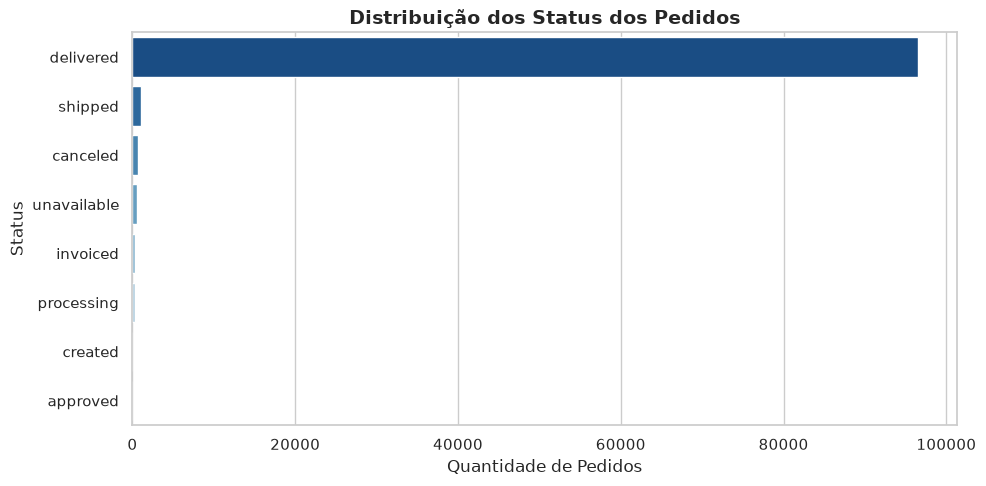

In [6]:
# 6.1 Status dos Pedidos
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=data['orders'], y='order_status', 
                   order=data['orders']['order_status'].value_counts().index, palette='Blues_r')
plt.title('Distribuição dos Status dos Pedidos', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade de Pedidos')
plt.ylabel('Status')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '01_distribuicao_status_pedidos.png'))
plt.show()


/run/user/1000/snap.antigravity/ipykernel_43656/2846118145.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data['order_payments'], x='payment_type',


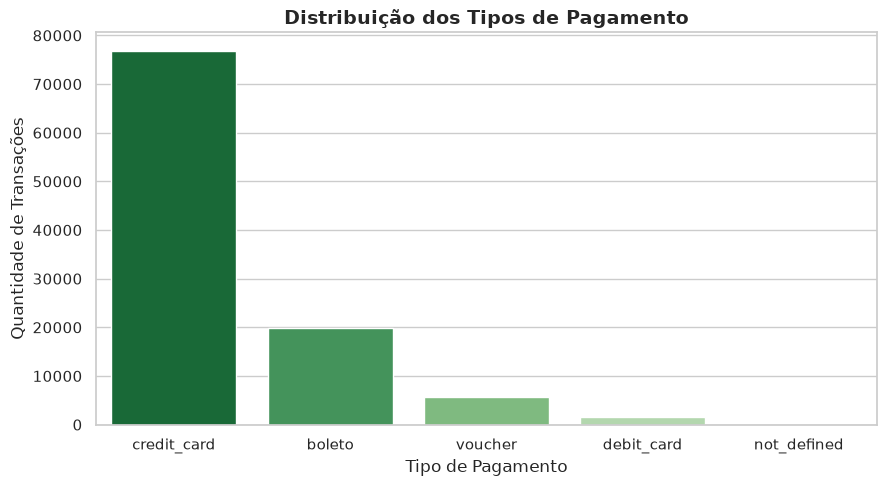

In [7]:
# 6.2 Tipos de Pagamento
plt.figure(figsize=(9, 5))
ax = sns.countplot(data=data['order_payments'], x='payment_type', 
                   order=data['order_payments']['payment_type'].value_counts().index, palette='Greens_r')
plt.title('Distribuição dos Tipos de Pagamento', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de Pagamento')
plt.ylabel('Quantidade de Transações')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '02_distribuicao_tipos_pagamento.png'))
plt.show()


/run/user/1000/snap.antigravity/ipykernel_43656/3114965671.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data['order_reviews'], x='review_score', palette='magma')


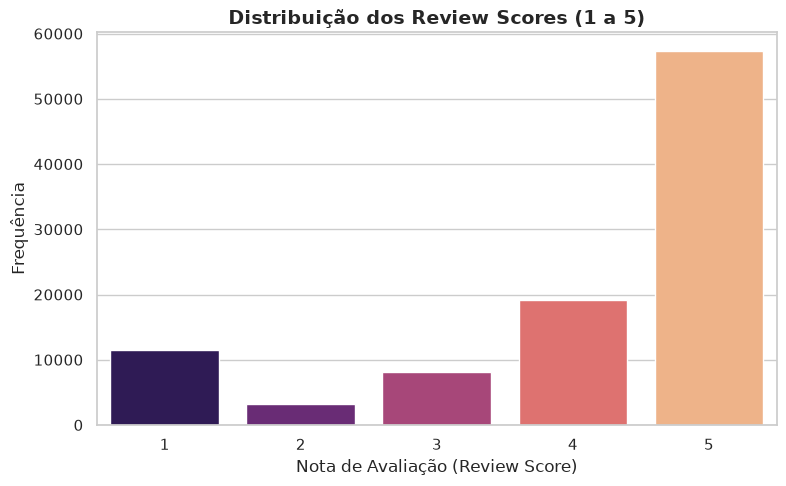

In [8]:
# 6.3 Distribuição das Notas de Avaliação
plt.figure(figsize=(8, 5))
sns.countplot(data=data['order_reviews'], x='review_score', palette='magma')
plt.title('Distribuição dos Review Scores (1 a 5)', fontsize=14, fontweight='bold')
plt.xlabel('Nota de Avaliação (Review Score)')
plt.ylabel('Frequência')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '03_distribuicao_notas_avaliacao.png'))
plt.show()


/run/user/1000/snap.antigravity/ipykernel_43656/2790115192.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_cats.index, x=top_cats.values, palette='viridis')


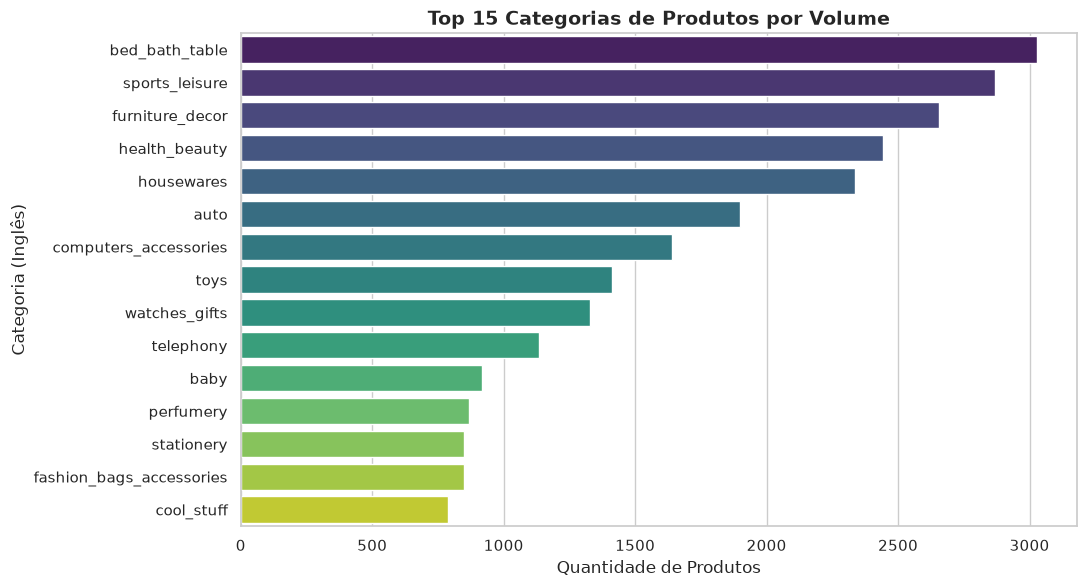

In [9]:
# 6.4 Top 15 Categorias de Produtos
products_cat = data['products'].merge(data['category_translation'], on='product_category_name', how='left')
top_cats = products_cat['product_category_name_english'].value_counts().head(15)

plt.figure(figsize=(11, 6))
sns.barplot(y=top_cats.index, x=top_cats.values, palette='viridis')
plt.title('Top 15 Categorias de Produtos por Volume', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade de Produtos')
plt.ylabel('Categoria (Inglês)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '04_top15_categorias.png'))
plt.show()


/run/user/1000/snap.antigravity/ipykernel_43656/872021256.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_c_states.index, y=top_c_states.values, ax=axes[0], palette='rocket')
/run/user/1000/snap.antigravity/ipykernel_43656/872021256.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_s_states.index, y=top_s_states.values, ax=axes[1], palette='mako')


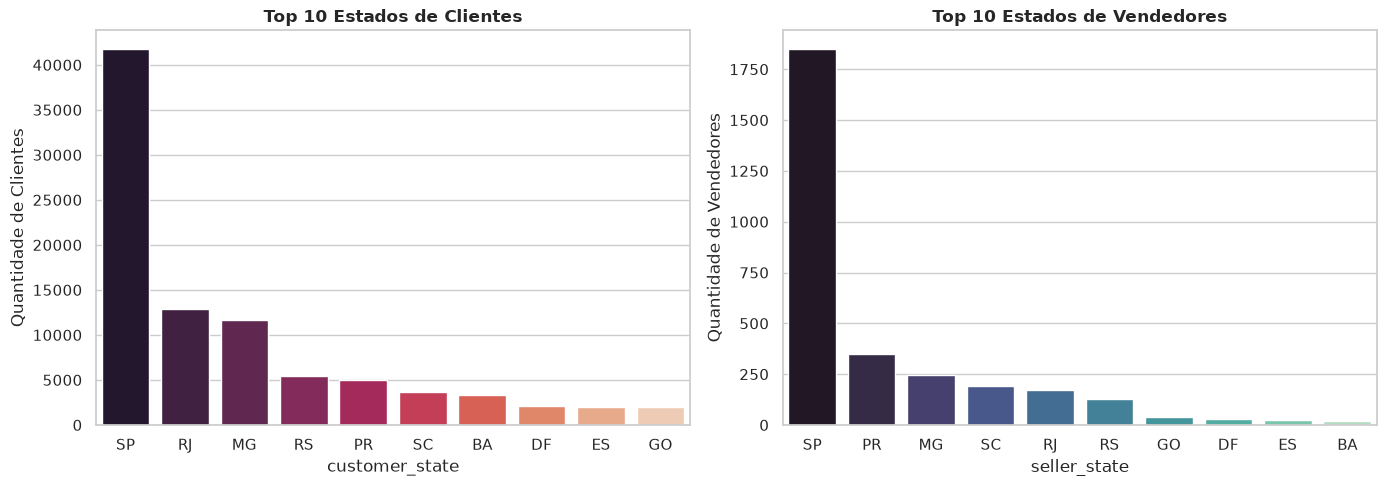

In [10]:
# 6.5 Distribuição Geográfica de Clientes e Vendedores por Estado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_c_states = data['customers']['customer_state'].value_counts().head(10)
sns.barplot(x=top_c_states.index, y=top_c_states.values, ax=axes[0], palette='rocket')
axes[0].set_title('Top 10 Estados de Clientes', fontweight='bold')
axes[0].set_ylabel('Quantidade de Clientes')

top_s_states = data['sellers']['seller_state'].value_counts().head(10)
sns.barplot(x=top_s_states.index, y=top_s_states.values, ax=axes[1], palette='mako')
axes[1].set_title('Top 10 Estados de Vendedores', fontweight='bold')
axes[1].set_ylabel('Quantidade de Vendedores')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '05_top10_estados_clientes.png'))
plt.show()


## 7. Conclusão da Visão Geral

- O dataset contém **99.441 pedidos** realizados por **96.096 clientes únicos** abastecidos por **3.095 vendedores**.
- 97% dos pedidos possuem status `delivered`.
- O meio de pagamento predominante é o **cartão de crédito**, seguido pelo **boleto**.
- A maior parte dos clientes e vendedores está concentrada no estado de **São Paulo (SP)**.